LeanDojo Demo
=============

This notebook demonstrates the main features of LeanDojo (using Lean 4). Please refer to the [documentation](https://leandojo.readthedocs.io/en/latest/) for more details.

In [1]:
# import time
# import ray

# def progress(i, n, start):
#     elapsed = time.time() - start
#     frac = (i + 1) / n
#     eta = (elapsed / frac - elapsed) if frac > 0 else float("inf")
#     bar_len = 24
#     filled = int(bar_len * frac)
#     bar = "[" + "#" * filled + "-" * (bar_len - filled) + "]"
#     print(f"\r{bar} step {i+1}/{n} | elapsed {elapsed:5.1f}s | eta {eta:5.1f}s", end="")

# steps = 3
# start = time.time()

# ray.shutdown()
# progress(0, steps, start)

# # Pick something comfortably above the 75 MiB minimum
# ray.init(ignore_reinit_error=True, include_dashboard=False, object_store_memory=512 * 1024 * 1024)
# progress(1, steps, start)

# print("\nRay initialized:", ray.is_initialized())
# progress(2, steps, start)
# print("\nDone.")


In [2]:
# Cell 1: Set up environment with verbose logging
import os
import sys

# Set GitHub access token
os.environ["GITHUB_ACCESS_TOKEN"] = "YOUR_GITHUB_TOKEN_HERE"


# Cell 2: Import and trace (or load from cache if exists)
from pathlib import Path

from lean_dojo import *
repo = LeanGitRepo(
    "https://github.com/leanprover-community/mathlib4",
    "29dcec074de168ac2bf835a77ef68bbe069194c5",
)

# Check if traced repo already exists on disk
dst_dir = Path("traced_mathlib4")
traced_path = dst_dir / repo.name  # e.g., traced_mathlib4/mathlib4


In [3]:

# Cell 2: Import and trace (or load from cache if exists)
from pathlib import Path

from lean_dojo import *
repo = LeanGitRepo(
    "https://github.com/leanprover-community/mathlib4",
    "29dcec074de168ac2bf835a77ef68bbe069194c5",
)

# Check if traced repo already exists on disk
dst_dir = Path("traced_mathlib4")
traced_path = dst_dir / repo.name  # e.g., traced_mathlib4/mathlib4

if traced_path.exists() and (traced_path / ".git").exists():
    print(f"Loading existing traced repo from {traced_path}...")
    traced_repo = TracedRepo.load_from_disk(traced_path)
    traced_repo.check_sanity()
    print(f"Loaded successfully!")
else:
    print(f"Tracing repo (this may take a while)...")
    traced_repo = trace(repo, dst_dir=dst_dir)

Loading existing traced repo from traced_mathlib4\mathlib4...


2026-01-11 18:39:44,412	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
c:\Users\chowdhary\Desktop\lean-dojo\.venv\Lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
100%|██████████| 5674/5674 [04:53<00:00, 19.34it/s]  


Loaded successfully!


## Extract Data from Lean

In [ ]:
data = []

for thm in traced_repo.get_traced_theorems():
    if not thm.has_tactic_proof():
        continue
    proof = thm.get_tactic_proof()
    if proof is None:
        continue
    theorem = thm.get_theorem_statement()
    data.append((theorem, proof))

len(data)


In [5]:
import json
# json.dump(data, open("complete_proofs.json", "wt"))

In [9]:
data = json.load(open("complete_proofs.json", "rt"))
# print(data)

In [10]:
data[0]

['theorem cardinal_mk_lift_le_mul :\n    Cardinal.lift.{u} #{ x : A // IsAlgebraic R x } ≤ Cardinal.lift.{v} #R[X] * ℵ₀ :=',
 "by\n  rw [← mk_uLift, ← mk_uLift]\n  choose g hg₁ hg₂ using fun x : { x : A | IsAlgebraic R x } => x.coe_prop\n  refine lift_mk_le_lift_mk_mul_of_lift_mk_preimage_le g fun f => ?_\n  rw [lift_le_aleph0, le_aleph0_iff_set_countable]\n  suffices MapsTo (↑) (g ⁻¹' {f}) (f.rootSet A) from\n    this.countable_of_injOn Subtype.coe_injective.injOn (f.rootSet_finite A).countable\n  rintro x (rfl : g x = f)\n  exact mem_rootSet.2 ⟨hg₁ x, hg₂ x⟩"]

In [11]:
# Export premises to current working directory
from pathlib import Path

import networkx as nx
from tqdm import tqdm  # Add progress bar

def export_premises(traced_repo: TracedRepo, dst_path: Path) -> None:
    """Export all premise definitions in a traced repo to ``dst_path``."""
    oup_path = dst_path / "corpus.jsonl"
    num_premises = 0

    with oup_path.open("wt") as oup:
        G = traced_repo.traced_files_graph

        tf_nodes = list(reversed(list(nx.topological_sort(G))))
        for tf_node in tqdm(tf_nodes, desc="Exporting premises", unit="file"):
            tf = G.nodes[tf_node]["traced_file"]
            imports = [str(_) for _ in G.successors(tf_node)]
            premises = tf.get_premise_definitions()
            num_premises += len(premises)
            oup.write(
                json.dumps(
                    {"path": str(tf.path), "imports": imports, "premises": premises}
                )
                + "\n"
            )
    logger.info(
        f"{num_premises} theorems/definitions from {len(traced_repo.traced_files)} files saved to {oup_path}"
    )



# Call export_premises with the traced_repo already in memory
export_premises(traced_repo, dst_path=Path("."))

print(f"Premises exported to: {Path('.').absolute() / 'corpus.jsonl'}")

Exporting premises:   0%|          | 0/5674 [00:00<?, ?file/s]

Exporting premises: 100%|██████████| 5674/5674 [02:20<00:00, 40.44file/s] 
2026-01-12 11:45:07.860 | INFO     | __main__:export_premises:27 - 180973 theorems/definitions from 5674 files saved to corpus.jsonl


Premises exported to: c:\Users\chowdhary\Desktop\lean-dojo\corpus.jsonl


In [15]:

print(f"Traced repo: {traced_repo}")
print(f"Number of ztraced files: {len(list(traced_repo.traced_files_graph.nodes()))}")

Traced repo: TracedRepo(repo=LeanGitRepo(url='C:\\Users\\chowdhary\\Desktop\\lean-dojo\\traced_mathlib4\\mathlib4', commit='29dcec074de168ac2bf835a77ef68bbe069194c5'), dependencies={'lean4': LeanGitRepo(url='https://github.com/leanprover/lean4', commit='3b58e0649156610ce3aeed4f7b5c652340c668d4'), 'batteries': LeanGitRepo(url='https://github.com/leanprover-community/batteries', commit='bba0af6e930ebcbabfacf021b21dd881d58aaa9d'), 'Qq': LeanGitRepo(url='https://github.com/leanprover-community/quote4', commit='a7bfa63f5dddbcab2d4e0569c4cac74b2585e2c6'), 'aesop': LeanGitRepo(url='https://github.com/leanprover-community/aesop', commit='a64fe24aa94e21404940e9217363a9a1ed9a33a6'), 'proofwidgets': LeanGitRepo(url='https://github.com/leanprover-community/ProofWidgets4', commit='d1b33202c3a29a079f292de65ea438648123b635'), 'Cli': LeanGitRepo(url='https://github.com/leanprover/lean4-cli', commit='a11566029bd9ec4f68a65394e8c3ff1af74c1a29'), 'importGraph': LeanGitRepo(url='https://github.com/leanprov

In [3]:
repo.get_config("lean-toolchain")

NameError: name 'repo' is not defined

In [18]:
traced_repo.traced_files_graph

In [26]:
import json

# Extract nodes and edges in a simpler format
graph_json = {
    "nodes": [
        {
            "id": node_id,
            "path": node_id,
            # Add other node attributes if needed
        }
        for node_id in traced_repo.traced_files_graph.nodes()
    ],
    "edges": [
        {
            "source": source,
            "target": target,
            "module": traced_repo.traced_files_graph.edges[source, target].get("module", "")
        }
        for source, target in traced_repo.traced_files_graph.edges()
    ]
}

# Save to file
with open("traced_files_graph.json", "w", encoding="utf-8") as f:
    json.dump(graph_json, f, indent=2, ensure_ascii=False)

print(f"Saved graph with {len(graph_json['nodes'])} nodes and {len(graph_json['edges'])} edges")

Saved graph with 5674 nodes and 4964 edges


In [8]:
traced_file = traced_repo.get_traced_file("Mathlib/Algebra/BigOperators/Pi.lean")
thms = list(traced_file.get_traced_theorems())

print("theorems in file:", len(thms))
thm = thms[0]
print("example theorem:", thm.theorem.full_name)

# tactics
tacs = thm.get_traced_tactics(atomic_only=False)
print("tactics (non-atomic):", len(tacs))
print("first tactic:", tacs[0].tactic if tacs else None)

# theorem-level premises
prems = list(thm.get_premise_full_names())
print("theorem premises:", len(prems))
print("first prem:", prems[0] if prems else None)

# tactic-level provenance (often sparser)
if tacs:
    annotated, provenances = tacs[0].get_annotated_tactic()
    print("provenances for first tactic:", len(provenances))


theorems in file: 13
example theorem: Pi.list_prod_apply
tactics (non-atomic): 0
first tactic: None
theorem premises: 0
first prem: None


# Mathlib 4 : Algebra

In [6]:
from tqdm import tqdm
import time, json
from pathlib import Path
from collections import defaultdict

# ------------------------------------------------------------
# Outputs
# ------------------------------------------------------------
OUT_EDGES_JSONL    = "tripartite_edges_all.jsonl"          # one row per (theorem, tactic)
OUT_THEOREMS_JSONL = "theorem_registry_all.jsonl"          # one row per theorem (includes term-style proofs)
OUT_PREMISES_JSONL = "premise_registry_unique.jsonl"       # unique premise constants seen in prov annotations

# ------------------------------------------------------------
# Collect all traced files
# ------------------------------------------------------------
TARGET_FILES = [str(tf.lean_file.path) for tf in traced_repo.traced_files]

# ------------------------------------------------------------
# First pass: count totals (with ETA via tqdm)
# ------------------------------------------------------------
total_theorems_all = 0
total_theorems_tactic = 0
total_tactics = 0

t0 = time.time()
for file_path in TARGET_FILES:
    tf = traced_repo.get_traced_file(file_path)
    traced_thms = tf.get_traced_theorems()

    total_theorems_all += len(traced_thms)
    for tt in traced_thms:
        n = tt.get_num_tactics()
        if n > 0:
            total_theorems_tactic += 1
            total_tactics += n

elapsed = time.time() - t0
print(
    f"Counted: theorems(all)={total_theorems_all}, "
    f"theorems(with tactics)={total_theorems_tactic}, tactics={total_tactics} "
    f"in {elapsed:.1f}s"
)

# ------------------------------------------------------------
# Helpers: robust premise key extraction
# ------------------------------------------------------------
def _prem_name(p: dict) -> str | None:
    # LeanDojo commonly uses fullName / defPath, but be defensive.
    return (
        p.get("fullName")
        or p.get("full_name")
        or p.get("name")
        or p.get("lemma")
    )

def _prem_path(p: dict) -> str | None:
    return p.get("defPath") or p.get("def_path") or p.get("file") or p.get("path")

# ------------------------------------------------------------
# Main pass: write 3 registries with progress + ETA
# ------------------------------------------------------------
edges_written = 0
theorems_written = 0

# Unique premise registry (dedupe by (name, defPath))
premise_seen = set()
premise_written = 0

t0 = time.time()

with open(OUT_EDGES_JSONL, "w", encoding="utf-8") as f_edges, \
     open(OUT_THEOREMS_JSONL, "w", encoding="utf-8") as f_thms, \
     open(OUT_PREMISES_JSONL, "w", encoding="utf-8") as f_prems:

    # Progress is over ALL theorems (includes term-style proofs)
    with tqdm(total=total_theorems_all, desc="Processing theorems", unit="thm") as pbar:
        for file_path in TARGET_FILES:
            tf = traced_repo.get_traced_file(file_path)
            traced_thms = tf.get_traced_theorems()

            for tt in traced_thms:
                # ----------------------------
                # 1) Theorem registry (complete over traced_theorems)
                # ----------------------------
                num_tactics = tt.get_num_tactics()
                thm_rec = {
                    "theorem": tt.theorem.full_name,
                    "file": str(tt.theorem.file_path),
                    "num_tactics": int(num_tactics),
                    "has_tactics": bool(num_tactics > 0),
                }
                f_thms.write(json.dumps(thm_rec, ensure_ascii=False) + "\n")
                theorems_written += 1

                # ----------------------------
                # 2) Edge registry (only if tactic-style proof exists)
                # ----------------------------
                if num_tactics > 0:
                    for tac in tt.get_traced_tactics():
                        try:
                            annotated_tac, prov = tac.get_annotated_tactic()
                        except Exception:
                            # Fall back: keep raw tactic, no premise annotations
                            annotated_tac, prov = tac.tactic, []

                        # Write edge row
                        edge_rec = {
                            "theorem": tt.theorem.full_name,
                            "file": str(tt.theorem.file_path),
                            "tactic": tac.tactic,
                            "annotated_tactic": annotated_tac,
                            "premises": prov,  # raw LeanDojo premise dicts (when available)
                            "premise_full_names": [
                                _prem_name(p) for p in prov if isinstance(p, dict) and _prem_name(p) is not None
                            ],
                            "state_before": tac.state_before,
                            "state_after": tac.state_after,
                        }
                        f_edges.write(json.dumps(edge_rec, ensure_ascii=False) + "\n")
                        edges_written += 1

                        # ----------------------------
                        # 3) Unique premise registry (from prov annotations)
                        # ----------------------------
                        for p in prov:
                            if not isinstance(p, dict):
                                continue
                            nm = _prem_name(p)
                            dp = _prem_path(p)
                            if nm is None:
                                continue
                            key = (nm, dp)
                            if key in premise_seen:
                                continue
                            premise_seen.add(key)

                            prem_rec = {
                                "full_name": nm,
                                "defPath": dp,
                                # keep any extra metadata that might be useful
                                "raw": p,
                            }
                            f_prems.write(json.dumps(prem_rec, ensure_ascii=False) + "\n")
                            premise_written += 1

                # Update progress/ETA
                pbar.update(1)
                pbar.set_postfix({
                    "edges": edges_written,
                    "premises": premise_written,
                    "file": Path(file_path).name,
                })

elapsed = time.time() - t0
rate_thm = theorems_written / max(elapsed, 1e-9)
rate_edge = edges_written / max(elapsed, 1e-9)
print(
    f"done:\n"
    f"  theorems: {theorems_written} -> {OUT_THEOREMS_JSONL}\n"
    f"  edges:    {edges_written} -> {OUT_EDGES_JSONL}\n"
    f"  premises: {premise_written} unique -> {OUT_PREMISES_JSONL}\n"
    f"  elapsed:  {elapsed:.1f}s  (~{rate_thm:.1f} thm/s, ~{rate_edge:.1f} edges/s)"
)


Counted: theorems(all)=126797, theorems(with tactics)=64034, tactics=303870 in 88.0s


Processing theorems: 100%|██████████| 126797/126797 [04:33<00:00, 462.78thm/s, edges=303870, premises=3240, file=Venn.lean]                            

done:
  theorems: 126797 -> theorem_registry_all.jsonl
  edges:    303870 -> tripartite_edges_all.jsonl
  premises: 3240 unique -> premise_registry_unique.jsonl
  elapsed:  274.1s  (~462.6 thm/s, ~1108.7 edges/s)


In [7]:
import json

OUT_EDGES_JSONL = "tripartite_edges_all.jsonl"
OUT_THEOREMS_JSONL = "theorem_registry_all.jsonl"
OUT_PREMISES_JSONL = "premise_registry_unique.jsonl"

# Load all edges
with open(OUT_EDGES_JSONL, "r", encoding="utf-8") as f:
    edges = [json.loads(line) for line in f if line.strip()]

# Load all theorems
with open(OUT_THEOREMS_JSONL, "r", encoding="utf-8") as f:
    theorems = [json.loads(line) for line in f if line.strip()]

# Load all premises
with open(OUT_PREMISES_JSONL, "r", encoding="utf-8") as f:
    premises = [json.loads(line) for line in f if line.strip()]

print(f"Loaded {len(edges)} edges")
print(f"Loaded {len(theorems)} theorems")
print(f"Loaded {len(premises)} premises")

Loaded 303870 edges
Loaded 126797 theorems
Loaded 3240 premises


In [8]:
edges[1:4]

[{'theorem': 'not_isPrimePow_zero',
  'file': 'Mathlib\\Algebra\\IsPrimePow.lean',
  'tactic': "simp only [isPrimePow_def, not_exists, not_and', and_imp]",
  'annotated_tactic': "simp only [isPrimePow_def, not_exists, not_and', and_imp]",
  'premises': [],
  'premise_full_names': [],
  'state_before': 'R : Type u_1\ninst✝¹ : CommMonoidWithZero R\nn p : R\nk : ℕ\ninst✝ : NoZeroDivisors R\n⊢ ¬IsPrimePow 0',
  'state_after': 'R : Type u_1\ninst✝¹ : CommMonoidWithZero R\nn p : R\nk : ℕ\ninst✝ : NoZeroDivisors R\n⊢ ∀ (x : R) (x_1 : ℕ), 0 < x_1 → x ^ x_1 = 0 → ¬Prime x'},
 {'theorem': 'not_isPrimePow_zero',
  'file': 'Mathlib\\Algebra\\IsPrimePow.lean',
  'tactic': 'intro x n _hn hx',
  'annotated_tactic': 'intro x n _hn hx',
  'premises': [],
  'premise_full_names': [],
  'state_before': 'R : Type u_1\ninst✝¹ : CommMonoidWithZero R\nn p : R\nk : ℕ\ninst✝ : NoZeroDivisors R\n⊢ ∀ (x : R) (x_1 : ℕ), 0 < x_1 → x ^ x_1 = 0 → ¬Prime x',
  'state_after': 'R : Type u_1\ninst✝¹ : CommMonoidWithZero 

In [5]:
# import networkx as nx
# import matplotlib.pyplot as plt
# import json
# from collections import defaultdict, Counter
# import numpy as np
# OUT_JSONL = "tripartite_edges.jsonl"
# # Load the tripartite network data
# edges = []
# theorems = set()
# tactics = set()
# premises = set()
# theorem_tactic_counts = defaultdict(int)  # Count tactics per theorem

# with open(OUT_JSONL, "r", encoding="utf-8") as f:
#     for line in f:
#         rec = json.loads(line)
#         theorem = rec["theorem"]
#         tactic = rec["tactic"]
#         theorem_premises = [p["full_name"] for p in rec["premises"]]
        
#         theorems.add(theorem)
#         tactics.add(tactic)
#         premises.update(theorem_premises)
        
#         # Count tactics per theorem (proof length)
#         theorem_tactic_counts[theorem] += 1
        
#         # Add edges: theorem -> tactic, tactic -> premises
#         edges.append(("theorem_" + theorem, "tactic_" + tactic))
#         for premise in theorem_premises:
#             edges.append(("tactic_" + tactic, "premise_" + premise))

# # Create proof length distribution
# proof_lengths = list(theorem_tactic_counts.values())
# proof_length_counter = Counter(proof_lengths)

# # Create tripartite graph
# G = nx.Graph()
# G.add_edges_from(edges)

# # Create node sets for visualization
# theorem_nodes = ["theorem_" + t for t in theorems]
# tactic_nodes = ["tactic_" + t for t in tactics]
# premise_nodes = ["premise_" + p for p in premises]

# print(f"Tripartite network statistics:")
# print(f"Theorems: {len(theorems)}")
# print(f"Tactics: {len(tactics)}")
# print(f"Premises: {len(premises)}")
# print(f"Total edges: {len(edges)}")
# print(f"\nProof length statistics:")
# print(f"Average proof length: {np.mean(proof_lengths):.2f} tactics")
# print(f"Median proof length: {np.median(proof_lengths):.0f} tactics")
# print(f"Max proof length: {max(proof_lengths)} tactics")
# print(f"Min proof length: {min(proof_lengths)} tactics")

# # Visualize a subset for clarity (full graph would be too dense)
# subset_theorems = list(theorems)[:10]
# subset_theorem_nodes = ["theorem_" + t for t in subset_theorems]

# # Get connected tactics and premises for these theorems
# connected_nodes = set(subset_theorem_nodes)
# for node in subset_theorem_nodes:
#     connected_nodes.update(G.neighbors(node))
#     for neighbor in G.neighbors(node):
#         connected_nodes.update(G.neighbors(neighbor))

# subgraph = G.subgraph(connected_nodes)

# # Create circular layout
# pos = nx.circular_layout(subgraph)


Tripartite network statistics:
Theorems: 10202
Tactics: 28549
Premises: 173
Total edges: 38518

Proof length statistics:
Average proof length: 3.74 tactics
Median proof length: 2 tactics
Max proof length: 146 tactics
Min proof length: 1 tactics


In [6]:
premises

{'AddConstMapClass.map_add_zsmul',
 'AddMonoid.End.mulLeft',
 'AddMonoidAlgebra.of_apply',
 'AddSubmonoid.prod',
 'Algebra',
 'AlgebraicGeometry.AffineTargetMorphismProperty.IsLocal.RespectsIso',
 'AlgebraicGeometry.LocallyRingedSpace.Hom.val',
 'And.left',
 'Bot.bot',
 'CategoryTheory.Category.comp_id',
 'CategoryTheory.Iso.hom_inv_id',
 'CategoryTheory.Limits.zero_comp',
 'CategoryTheory.Mono',
 'CategoryTheory.NatTrans.naturality_assoc',
 'CategoryTheory.Preadditive.sub_comp',
 'CategoryTheory.Pretriangulated.Triangle.mor₂',
 'CategoryTheory.ShortComplex.Exact',
 'CategoryTheory.ShortComplex.Exact.lift_f',
 'CategoryTheory.ShortComplex.Hom.τ₁',
 'CategoryTheory.ShortComplex.Hom.τ₂',
 'CategoryTheory.ShortComplex.Hom.τ₃',
 "CategoryTheory.ShortComplex.RightHomologyMapData.rightHomologyMap'_eq",
 'CategoryTheory.ShortComplex.ShortExact.δ_eq',
 'CategoryTheory.ShortComplex.SnakeInput.L₁',
 "CategoryTheory.ShortComplex.SnakeInput.L₂'",
 "CategoryTheory.ShortComplex.SnakeInput.δ_apply'",

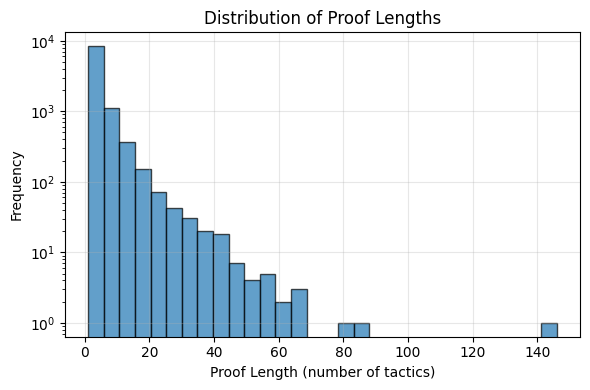

Counter({1: 4148,
         2: 2361,
         3: 941,
         5: 462,
         4: 456,
         6: 324,
         7: 275,
         8: 195,
         9: 188,
         10: 129,
         11: 114,
         13: 83,
         12: 75,
         14: 52,
         15: 40,
         16: 39,
         17: 32,
         19: 31,
         18: 27,
         20: 24,
         21: 20,
         22: 15,
         26: 14,
         28: 13,
         23: 13,
         25: 13,
         31: 11,
         24: 10,
         42: 10,
         30: 9,
         27: 8,
         29: 7,
         37: 6,
         34: 5,
         35: 5,
         32: 3,
         39: 3,
         44: 3,
         36: 3,
         38: 3,
         33: 3,
         40: 3,
         51: 2,
         50: 2,
         56: 2,
         49: 2,
         48: 2,
         47: 2,
         66: 2,
         84: 1,
         58: 1,
         57: 1,
         43: 1,
         146: 1,
         55: 1,
         79: 1,
         45: 1,
         59: 1,
         68: 1,
         41: 1,
      

In [38]:
import matplotlib.pyplot as plt

# Plot proof length distribution
plt.figure(figsize=(6, 4))

# Single plot: Histogram of proof lengths with log y-axis
plt.hist(proof_lengths, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Proof Length (number of tactics)')
plt.ylabel('Frequency')
plt.title('Distribution of Proof Lengths')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

proof_length_counter

In [80]:
# Compute tactics by extracting the head tactic before the first '['
tactic_head_counts = Counter()

for tactic in tactics:
    # Extract the head tactic before the first '['
    head_tactic = tactic.split('[')[0].strip()
    tactic_head_counts[head_tactic] += 1

tactic_head_counts

Counter({'rw': 6714,
         'simp only': 2077,
         'simp': 1067,
         '· rw': 848,
         'simpa only': 504,
         'simp_rw': 488,
         'rwa': 423,
         'erw': 299,
         '· simp only': 257,
         'simpa': 225,
         '· simp': 161,
         'dsimp': 153,
         'dsimp only': 98,
         '· rwa': 58,
         '· simp_rw': 56,
         'exacts': 49,
         '· simpa only': 44,
         'classical\nrw': 33,
         'conv_rhs => rw': 31,
         'conv_lhs => rw': 28,
         '· erw': 24,
         'classical\n  rw': 23,
         'classical rw': 21,
         'field_simp': 19,
         '· intro h\n  rw': 17,
         'linear_combination (norm := (rw': 17,
         '· simpa': 17,
         'nth_rw 1': 17,
         'simp (config := { contextual := true })': 13,
         'push_cast': 13,
         "repeat' rw": 10,
         'simp_all': 10,
         'classical simp': 9,
         'nth_rw 2': 8,
         'simp?': 8,
         'simp_all only': 8,
         'linari

In [71]:
# Compute tactics by extracting the head tactic before the first '['
tactic_head_counts = Counter()

for tactic in tactics:
    # Extract the head tactic before the first '['
    head_tactic = tactic.split('[')[0].strip()
    tactic_head_counts[head_tactic] += 1

tactic_head_counts

Counter({'rw': 6714,
         'simp only': 2077,
         'simp': 1067,
         '· rw': 848,
         'simpa only': 504,
         'simp_rw': 488,
         'rwa': 423,
         'erw': 299,
         '· simp only': 257,
         'simpa': 225,
         '· simp': 161,
         'dsimp': 153,
         'dsimp only': 98,
         '· rwa': 58,
         '· simp_rw': 56,
         'exacts': 49,
         '· simpa only': 44,
         'classical\nrw': 33,
         'conv_rhs => rw': 31,
         'conv_lhs => rw': 28,
         '· erw': 24,
         'classical\n  rw': 23,
         'classical rw': 21,
         'field_simp': 19,
         '· intro h\n  rw': 17,
         'nth_rw 1': 17,
         'linear_combination (norm := (rw': 17,
         '· simpa': 17,
         'simp (config := { contextual := true })': 13,
         'push_cast': 13,
         'simp_all': 10,
         "repeat' rw": 10,
         'classical simp': 9,
         'simp_all only': 8,
         'simp?': 8,
         'nth_rw 2': 8,
         'linari

# Premises deep extraction: eh 

In [ ]:
"""
Premises Extraction Code
========================
Extracts tripartite edges with AST-identified premises and definition excerpts
from LeanDojo traced repositories.
"""

from __future__ import annotations

import json
import time
from pathlib import Path
from tqdm import tqdm
from 0_premises_extraction_code import *
# -----------------------------
# Main execution code (copy-paste into notebook)
# -----------------------------
# NOTE: Assumes traced_repo is already loaded in your notebook

# Get target files
TARGET_FILES = get_target_files(traced_repo, filter_pattern="Mathlib\\Algebra")
print(f"Found {len(TARGET_FILES)} target files")

# Run extraction
OUT_JSONL = "tripartite_edges_ast_idents_algebra_with_excerpt.jsonl"
edges_written = extract_premises_edges(
    traced_repo,
    TARGET_FILES,
    output_file=OUT_JSONL
)

print(f"\nExtraction complete! Wrote {edges_written} edges to {OUT_JSONL}")


Found 814 target files
Building local definition index...


Processing files: 100%|██████████| 814/814 [00:21<00:00, 37.33file/s]


Done: wrote 38196 edges in 21.8s (~1751.0 edges/s)
Output: tripartite_edges_ast_idents_algebra_with_excerpt.jsonl

Extraction complete! Wrote 38196 edges to tripartite_edges_ast_idents_algebra_with_excerpt.jsonl


# Random proving attempts w LEAN:  
aim was to check human proofs in mathlib but that didnt work

In [78]:
import json
import random
import re
import time
from collections import defaultdict
from lean_dojo import *

# ============================================================
# Progress bar (with ETA)
# ============================================================

def progress_bar(i, n, start_time, width=30, prefix=""):
    elapsed = time.time() - start_time
    rate = (i + 1) / elapsed if elapsed > 0 else 0.0
    remaining = (n - (i + 1)) / rate if rate > 0 else float("inf")
    filled = int(width * (i + 1) / n) if n > 0 else width
    bar = "█" * filled + "░" * (width - filled)
    eta_str = f"{remaining:6.1f}s" if remaining != float("inf") else "   infs"
    print(f"\r{prefix}[{bar}] {i+1}/{n} | ETA {eta_str}", end="")

# ============================================================
# Safe state helpers
# ============================================================

GOAL_MARK = "⊢"

def is_error(x):
    return isinstance(x, LeanError)

def is_finished(x):
    # LeanDojo uses ProofFinished to signal success
    return isinstance(x, ProofFinished)

def state_pp(x):
    # Only states have .pp
    return getattr(x, "pp", "")

def progressed(old_state, new_state):
    # If proof finished, that is "progress"
    if is_finished(new_state):
        return True
    return state_pp(old_state).strip() != state_pp(new_state).strip()

def extract_goal_block(state_pp_str: str):
    if GOAL_MARK not in state_pp_str:
        return ""
    idx = state_pp_str.rfind(GOAL_MARK)
    return state_pp_str[idx:].strip()

def extract_locals_with_types(state_pp_str: str):
    out = []
    for line in state_pp_str.splitlines():
        line = line.strip()
        if not line or line.startswith(GOAL_MARK):
            continue
        if " : " in line:
            name, ty = line.split(" : ", 1)
            name = name.strip()
            ty = ty.strip()
            if re.match(r"^[a-zA-Z_][a-zA-Z0-9_']*$", name):
                out.append((name, ty))
    return out

# ============================================================
# Tactic parsing / family mapping
# ============================================================

def tactic_family(tac: str):
    t = (tac or "").strip()
    if t.startswith(("simp_all",)):
        return "simp_all"
    if t.startswith(("simp_rw",)):
        return "simp_rw"
    if t.startswith(("simp",)):
        return "simp"
    if t.startswith(("rw", "rwa", "rewrite")):
        return "rw"
    if t.startswith(("intro", "intros", "rintro")):
        return "intro"
    if t.startswith(("cases", "rcases")):
        return "cases"
    if t.startswith(("ext", "ext1", "ext2")):
        return "ext"
    if t.startswith(("constructor",)):
        return "constructor"
    if t.startswith(("apply",)):
        return "apply"
    if t.startswith(("exact",)):
        return "exact"
    if t.startswith(("aesop",)):
        return "aesop"
    if t in {"rfl", "decide", "assumption"}:
        return t
    return "other"

def parse_bracket_lemmas(tac: str):
    t = tac or ""
    m = re.search(r"\[([^\]]+)\]", t)
    if not m:
        return []
    content = m.group(1)
    toks = []
    for raw in content.split(","):
        tok = raw.strip()
        if tok == "*":
            toks.append(tok)
        else:
            if re.match(r"^[A-Za-z_][A-Za-z0-9_'.]*$", tok):
                toks.append(tok)
    return toks

# ============================================================
# LeanDojo tactic execution
# ============================================================

def try_tac(dojo, state, tac_str):
    res = dojo.run_tac(state, tac_str)
    if is_error(res):
        return None
    return res

# ============================================================
# Family-aware execution with premises
# ============================================================

def run_family(dojo, state, family, recorded_edge):
    """
    Returns:
      - None on failure
      - ProofFinished on success
      - next state object on progress
    """
    pp0 = state_pp(state)
    locals_with_types = extract_locals_with_types(pp0)
    local_names = [n for n, _ in locals_with_types]
    goal = extract_goal_block(pp0)

    recorded_premises = recorded_edge.get("premises", []) or []
    recorded_tac = recorded_edge.get("tactic", "") or ""
    bracket_lemmas = parse_bracket_lemmas(recorded_tac)

    # Always-cheap closers
    for cheap in ["assumption", "rfl"]:
        ns = try_tac(dojo, state, cheap)
        if ns is not None and progressed(state, ns):
            return ns

    if family == "intro":
        if "⊢ ∀" in goal or "→" in goal:
            ns = try_tac(dojo, state, "intro")
            return ns
        return None

    if family == "simp":
        if "simp only" in recorded_tac and bracket_lemmas:
            lemmas_str = ", ".join(bracket_lemmas[:10])
            ns = try_tac(dojo, state, f"simp only [{lemmas_str}]")
            if ns is not None and progressed(state, ns):
                return ns

        if bracket_lemmas and "simp" in recorded_tac and "only" not in recorded_tac:
            lemmas = [x for x in bracket_lemmas if x != "*"]
            if lemmas:
                ns = try_tac(dojo, state, f"simp [{', '.join(lemmas[:10])}]")
                if ns is not None and progressed(state, ns):
                    return ns

        if recorded_premises:
            ns = try_tac(dojo, state, f"simp [{', '.join(recorded_premises[:10])}]")
            if ns is not None and progressed(state, ns):
                return ns

        useful = [n for n in local_names if n.startswith("h") or n.startswith("ih")]
        if useful:
            ns = try_tac(dojo, state, f"simp [{', '.join(useful[:10])}]")
            if ns is not None and progressed(state, ns):
                return ns

        for t in ["simp", "simp_all"]:
            ns = try_tac(dojo, state, t)
            if ns is not None and progressed(state, ns):
                return ns

        return None

    if family == "simp_all":
        ns = try_tac(dojo, state, "simp_all")
        if ns is not None and progressed(state, ns):
            return ns
        return run_family(dojo, state, "simp", recorded_edge)

    if family == "simp_rw":
        candidates = []
        candidates.extend([x for x in bracket_lemmas if x != "*"])
        candidates.extend(recorded_premises)
        candidates.extend([n for n in local_names if n.startswith("h") or n.startswith("ih")])

        for lem in candidates[:12]:
            ns = try_tac(dojo, state, f"simp_rw [{lem}]")
            if ns is not None:
                return ns
        return None

    if family == "rw":
        recorded_list = [x for x in bracket_lemmas if x != "*"]

        if recorded_list:
            ns = try_tac(dojo, state, f"rw [{', '.join(recorded_list[:8])}]")
            if ns is not None:
                return ns

        candidates = []
        candidates.extend(recorded_list)
        candidates.extend(recorded_premises)
        candidates.extend([n for n in local_names if n.startswith("h") or n.startswith("ih")])

        for lem in candidates[:20]:
            ns = try_tac(dojo, state, f"rw [{lem}]")
            if ns is not None:
                return ns

        return None

    if family == "cases":
        inductive_hints = ("Nat", "Fin", "Sum", "Prod", "Sigma", "Subtype", "Exists", "And", "Or")
        ranked = []
        for n, ty in locals_with_types:
            score = 0
            if any(h in ty for h in inductive_hints):
                score += 2
            if n in {"n", "m", "k"} or n.endswith("n") or n.endswith("m"):
                score += 1
            if n.startswith("h") or n.startswith("ih"):
                score -= 1
            ranked.append((score, n))
        ranked.sort(reverse=True)

        for _, n in ranked[:15]:
            ns = try_tac(dojo, state, f"cases {n}")
            if ns is not None:
                return ns
        return None

    if family == "ext":
        for t in ["ext", "ext1", "ext2"]:
            ns = try_tac(dojo, state, t)
            if ns is not None:
                return ns
        return None

    if family == "constructor":
        return try_tac(dojo, state, "constructor")

    if family == "exact":
        for n in local_names:
            ns = try_tac(dojo, state, f"exact {n}")
            if ns is not None:
                return ns
        for lem in recorded_premises[:10]:
            ns = try_tac(dojo, state, f"exact {lem}")
            if ns is not None:
                return ns
        return None

    if family == "apply":
        candidates = []
        candidates.extend([x for x in bracket_lemmas if x != "*"])
        candidates.extend(recorded_premises)

        for lem in candidates[:15]:
            ns = try_tac(dojo, state, f"apply {lem}")
            if ns is not None:
                return ns
        return None

    if family == "aesop":
        return try_tac(dojo, state, "aesop")

    if family in {"rfl", "decide", "assumption"}:
        return try_tac(dojo, state, family)

    # other: controlled high-yield bundle
    for t in ["simp", "simp_all", "aesop", "constructor", "ext", "assumption"]:
        ns = try_tac(dojo, state, t)
        if ns is not None and progressed(state, ns):
            return ns

    return None

# ============================================================
# Fallback bundle (cheap ATP-ish)
# ============================================================

FALLBACK_TACTICS = ["simp", "simp_all", "aesop", "linarith", "nlinarith", "ring"]

def fallback_bundle(dojo, state):
    for fb in FALLBACK_TACTICS:
        ns = try_tac(dojo, state, fb)
        if ns is not None and progressed(state, ns):
            return fb, ns
    return None, None

# ============================================================
# Main
# ============================================================

with open("tripartite_edges.jsonl", "r", encoding="utf-8") as f:
    edges = [json.loads(line) for line in f]

theorem_edges = defaultdict(list)
for e in edges:
    theorem_edges[e["theorem"]].append(e)

for thm in theorem_edges:
    theorem_edges[thm].sort(key=lambda x: len(x.get("state_before", "")))

print(f"Found {len(theorem_edges)} unique theorems with recorded tactics")

sample_theorems = random.sample(list(theorem_edges.keys()),
                                min(10, len(theorem_edges)))

results = []

for thm_name in sample_theorems:
    print(f"\n🔍 Sanity checking theorem: {thm_name}")
    first = theorem_edges[thm_name][0]
    file_path = first["file"].replace("\\", "/")

    try:
        theorem = Theorem(repo, file_path, thm_name)
        dojo, state = Dojo(theorem).__enter__()

        fams = [tactic_family(e["tactic"]) for e in theorem_edges[thm_name]]
        print(f"  Initial state ID: {state.id}")
        print(f"  Replaying {len(fams)} tactic families...")

        matches = 0
        start = time.time()

        for i, (fam, edge) in enumerate(zip(fams, theorem_edges[thm_name])):
            progress_bar(i, len(fams), start, prefix="  ")

            ns = run_family(dojo, state, fam, edge)

            if ns is None:
                fb_name, fb_ns = fallback_bundle(dojo, state)
                if fb_ns is not None:
                    matches += 1
                    if is_finished(fb_ns):
                        print(f"\n    Step {i+1}: ~ {fam} failed, fallback ✓ {fb_name} → PROOF COMPLETE")
                        state = fb_ns
                        break
                    print(f"\n    Step {i+1}: ~ {fam} failed, fallback ✓ {fb_name} → State {fb_ns.id}")
                    state = fb_ns
                    continue

                print(f"\n    Step {i+1}: × {fam}")
                continue

            matches += 1
            if is_finished(ns):
                print(f"\n    Step {i+1}: ✓ {fam} → PROOF COMPLETE")
                state = ns
                break

            print(f"\n    Step {i+1}: ✓ {fam} → State {ns.id}")
            state = ns

        success_rate = matches / len(fams) if fams else 0.0
        print(f"  Result: {matches}/{len(fams)} steps succeeded ({success_rate:.1%})")

        results.append(success_rate)
        dojo.__exit__(None, None, None)

    except Exception as e:
        print(f"\n  FAILED: {e}")
        results.append(0.0)

avg = sum(results) / len(results) if results else 0.0
print("\n📊 Summary")
print(f"Theorems tested: {len(results)}")
print(f"Average success rate: {avg:.1%}")

if avg > 0.25:
    print("✅ Better baseline: bracket-lemma rw/simp + fallbacks are working.")
else:
    print("⚠️ Still low: to jump further you need real premise capture (lemmas used) into the JSON.")


Found 10202 unique theorems with recorded tactics

🔍 Sanity checking theorem: MvPolynomial.map_mapRange_eq_iff
  Initial state ID: 0
  Replaying 6 tactic families...
  [█████░░░░░░░░░░░░░░░░░░░░░░░░░] 1/6 | ETA    infs
    Step 1: ~ rfl failed, fallback ✓ aesop → State 1
  [██████████░░░░░░░░░░░░░░░░░░░░] 2/6 | ETA    3.7s
    Step 2: × rw
  [███████████████░░░░░░░░░░░░░░░] 3/6 | ETA    5.0s
    Step 3: × apply
  [████████████████████░░░░░░░░░░] 4/6 | ETA    3.4s
    Step 4: × rw
  [█████████████████████████░░░░░] 5/6 | ETA    2.0s
    Step 5: × intro
  [██████████████████████████████] 6/6 | ETA    0.0s
    Step 6: × apply
  Result: 1/6 steps succeeded (16.7%)

🔍 Sanity checking theorem: MulOneClass.ext
  Initial state ID: 0
  Replaying 5 tactic families...
  [██████░░░░░░░░░░░░░░░░░░░░░░░░] 1/5 | ETA    infs
    Step 1: ✓ intro → State 1
  [████████████░░░░░░░░░░░░░░░░░░] 2/5 | ETA    0.7s
    Step 2: × exact
  [██████████████████░░░░░░░░░░░░] 3/5 | ETA    0.9s
    Step 3: × rfl
  [██

# Pretty printing example theomroms for GPT

In [68]:
import json
import os

# Find the top 50 longest theorems by number of edges
theorem_lengths = []
for thm, edge_info in theorem_edges.items():
    if isinstance(edge_info, list):
        theorem_lengths.append((thm, len(edge_info)))
    else:
        theorem_lengths.append((thm, 1))

# Sort by length (descending) and take top 50
top_50_longest = sorted(theorem_lengths, key=lambda x: x[1], reverse=True)[:500]

# Collect all theorem data in a single structure
all_theorems_data = {
    "metadata": {
        "total_theorems": len(top_50_longest),
        "description": "Top 50 longest theorems by proof tree size"
    },
    "theorems": []
}

for rank, (thm, length) in enumerate(top_50_longest, 1):
    if thm in theorem_edges:
        edge_info = theorem_edges[thm]
        
        # Prepare data for JSON file with tree structure
        theorem_data = {
            "rank": rank,
            "theorem_name": thm,
            "proof_length": length,
            "proof_tree": {
                "nodes": {},  # state_id -> node_info
                "edges": []   # list of {from: state_id, to: state_id, tactic: str, premises: []}
            }
        }
        
        # Check if it's a list of dicts
        if isinstance(edge_info, list):
            for i, edge in enumerate(edge_info):
                if isinstance(edge, dict):
                    # Extract state information
                    state_before = edge.get('state_before')
                    state_after = edge.get('state_after')
                    tactic = edge.get('tactic')
                    premises = edge.get('premises', [])
                    
                    # Add nodes to the tree
                    if state_before and state_before not in theorem_data["proof_tree"]["nodes"]:
                        theorem_data["proof_tree"]["nodes"][state_before] = {
                            "state_id": state_before,
                            "is_initial": i == 0,
                            "is_terminal": False
                        }
                    
                    if state_after and state_after not in theorem_data["proof_tree"]["nodes"]:
                        theorem_data["proof_tree"]["nodes"][state_after] = {
                            "state_id": state_after,
                            "is_initial": False,
                            "is_terminal": False
                        }
                    
                    # Add edge to the tree
                    if state_before and state_after and tactic:
                        edge_data = {
                            "from": state_before,
                            "to": state_after,
                            "tactic": tactic
                        }
                        if premises:
                            edge_data["premises"] = premises
                        
                        theorem_data["proof_tree"]["edges"].append(edge_data)
                    
                    # Check for state mismatch with next edge
                    if i + 1 < len(edge_info) and isinstance(edge_info[i + 1], dict):
                        next_edge = edge_info[i + 1]
                        if ('state_after' in edge and 'state_before' in next_edge and 
                            edge['state_after'] != next_edge['state_before']):
                            edge_data["_state_mismatch_warning"] = "state_after != next_state_before"
            
            # Mark terminal nodes (nodes that don't have outgoing edges)
            outgoing_states = {edge["from"] for edge in theorem_data["proof_tree"]["edges"]}
            for state_id, node in theorem_data["proof_tree"]["nodes"].items():
                if state_id not in outgoing_states:
                    node["is_terminal"] = True
                        
        elif isinstance(edge_info, dict):
            # Handle single edge case
            state_before = edge_info.get('state_before')
            state_after = edge_info.get('state_after')
            tactic = edge_info.get('tactic')
            premises = edge_info.get('premises', [])
            
            # Add nodes
            if state_before:
                theorem_data["proof_tree"]["nodes"][state_before] = {
                    "state_id": state_before,
                    "is_initial": True,
                    "is_terminal": False
                }
            
            if state_after:
                theorem_data["proof_tree"]["nodes"][state_after] = {
                    "state_id": state_after,
                    "is_initial": False,
                    "is_terminal": True
                }
            
            # Add edge
            if state_before and state_after and tactic:
                edge_data = {
                    "from": state_before,
                    "to": state_after,
                    "tactic": tactic
                }
                if premises:
                    edge_data["premises"] = premises
                
                theorem_data["proof_tree"]["edges"].append(edge_data)
        
        # Add this theorem to the combined data
        all_theorems_data["theorems"].append(theorem_data)

# Save all theorems to a single JSON file
with open("top_50_proof_trees.json", 'w') as f:
    json.dump(all_theorems_data, f, indent=2)

print(f"Saved {len(all_theorems_data['theorems'])} theorems to top_50_proof_trees.json")

Saved 500 theorems to top_50_proof_trees.json


# visualize proof trees

In [77]:
if 'visualize_proof_tree' in sys.modules:
    del sys.modules['visualize_proof_tree']

from visualize_proof_tree import visualize_proof_trees_grid

# Load the JSON file
with open("top_50_proof_trees.json", 'r') as f:
    all_theorems_data = json.load(f)

# Extract theorem_data objects (the visualization function expects the format with 'theorem_name' and 'proof_tree')
theorem_list = []
for thm_data in all_theorems_data["theorems"]:
    # Convert to the format expected by visualize_proof_trees_grid
    theorem_data = {
        "theorem_name": thm_data["theorem_name"],
        "proof_tree": thm_data["proof_tree"]
    }
    theorem_list.append(theorem_data)

# Visualize first 16 in a 4x4 grid
html_path = visualize_proof_trees_grid(theorem_list[:], "proof_trees_grid.html")
print(f"Grid visualization saved to: {html_path}")
print(f"Total theorems loaded: {len(theorem_list)}")
print(f"Theorems visualized: {min(16, len(theorem_list))}")


Grid visualization saved to: proof_trees_grid.html
Total theorems loaded: 500
Theorems visualized: 16


: 

In [30]:
import json

for thm in sample_theorems:
    print(f"Theorem: {thm}")
    if thm in theorem_edges:
        edge_info = theorem_edges[thm]
        
        # Check if it's a list of dicts
        if isinstance(edge_info, list):
            print(f"  Found {len(edge_info)} edges:")
            for i, edge in enumerate(edge_info):
                print(f"    Edge {i+1}:")
                if isinstance(edge, dict):
                    print(json.dumps(edge, indent=6))
                else:
                    print(f"      {edge}")
        elif isinstance(edge_info, dict):
            print("  Single edge (dict):")
            print(json.dumps(edge_info, indent=4))
        else:
            print(f"  Raw value: {edge_info}")
    else:
        print(f"  Not found in theorem_edges")
    print()

Theorem: Function.support_pow
  Found 2 edges:
    Edge 1:
{
      "theorem": "Function.support_pow",
      "file": "Mathlib\\Algebra\\GroupWithZero\\Indicator.lean",
      "tactic": "ext",
      "annotated_tactic": "ext",
      "premises": [],
      "state_before": "\u03b9 : Type u_1\n\u03ba : Type u_2\nG\u2080 : Type u_3\nM\u2080 : Type u_4\nR : Type u_5\ninst\u271d\u00b9 : MonoidWithZero M\u2080\ninst\u271d : NoZeroDivisors M\u2080\nn : \u2115\nf : \u03b9 \u2192 M\u2080\nhn : n \u2260 0\n\u22a2 (support fun a => f a ^ n) = support f",
      "state_after": "case h\n\u03b9 : Type u_1\n\u03ba : Type u_2\nG\u2080 : Type u_3\nM\u2080 : Type u_4\nR : Type u_5\ninst\u271d\u00b9 : MonoidWithZero M\u2080\ninst\u271d : NoZeroDivisors M\u2080\nn : \u2115\nf : \u03b9 \u2192 M\u2080\nhn : n \u2260 0\nx\u271d : \u03b9\n\u22a2 (x\u271d \u2208 support fun a => f a ^ n) \u2194 x\u271d \u2208 support f"
}
    Edge 2:
{
      "theorem": "Function.support_pow",
      "file": "Mathlib\\Algebra\\GroupWit

## Interact with Lean Programmatically

In [21]:
repo

LeanGitRepo(url='https://github.com/leanprover-community/mathlib4', commit='29dcec074de168ac2bf835a77ef68bbe069194c5')

# Interact through Tactics

In [2]:
from lean_dojo import *


In [10]:
theorem = Theorem(repo, "Mathlib/Algebra/BigOperators/Pi.lean", "pi_eq_sum_univ")

# For some theorems, it might take a few minutes.
dojo, state_0 = Dojo(theorem).__enter__()

In [11]:
state_0

TacticState(pp='ι : Type u_1\ninst✝² : Fintype ι\ninst✝¹ : DecidableEq ι\nR : Type u_2\ninst✝ : Semiring R\nx : ι → R\n⊢ x = ∑ i : ι, x i • fun j => if i = j then 1 else 0', id=0, message=None)

In [13]:
print(state_0.pp)

ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
x : ι → R
⊢ x = ∑ i : ι, x i • fun j => if i = j then 1 else 0


In [14]:
state_1 = dojo.run_tac(state_0, "revert x")

print(state_1.pp)

ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
⊢ ∀ (x : ι → R), x = ∑ i : ι, x i • fun j => if i = j then 1 else 0


In [15]:
state_2 = dojo.run_tac(state_0, "hello world!")

state_2

LeanError(error='<stdin>:1:1: unknown tactic')

In [16]:
dojo.run_tac(state_2, "skip")

: 

In [17]:
dojo.run_tac(state_0, "sorry")

ProofGivenUp()

In [18]:
print(state_0.pp)

ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
x : ι → R
⊢ x = ∑ i : ι, x i • fun j => if i = j then 1 else 0


In [19]:
state_3 = dojo.run_tac(state_0, "ext")

print(state_3.pp)

case h
ι : Type u_1
inst✝² : Fintype ι
inst✝¹ : DecidableEq ι
R : Type u_2
inst✝ : Semiring R
x : ι → R
x✝ : ι
⊢ x x✝ = (∑ i : ι, x i • fun j => if i = j then 1 else 0) x✝


In [20]:
state_4 = dojo.run_tac(state_3, "simp")

print(state_4)

ProofFinished(tactic_state_id=3, message='')


In [21]:
dojo.is_successful

True

### Interact through Commands

In [13]:
entry = (repo, "Mathlib/Algebra/Module/Equiv.lean", 953)  # (repo, file_path, line_nb)
dojo, state_0 = Dojo(entry).__enter__()

In [14]:
state_0

CommandState(id=0, message=None)

In [15]:
dojo.run_cmd(state_0, "#eval 1")

CommandState(id=1, message='1')

In [16]:
dojo.run_cmd(state_0, "#eval x")

LeanError(error="unknown identifier 'x'")

In [17]:
state_1 = dojo.run_cmd(state_0, "def x := 1")

state_1

CommandState(id=3, message='')

In [18]:
dojo.run_cmd(state_1, "#eval x")

CommandState(id=4, message='1')

In [19]:
dojo.run_cmd(state_0, "#check addMonoidHomLequivNat")

CommandState(id=5, message='addMonoidHomLequivNat.{u_17, u_18, u_19} {A : Type u_17} {B : Type u_18} (R : Type u_19) [Semiring R] [AddCommMonoid A]\n[AddCommMonoid B] [Module R B] : (A →+ B) ≃ₗ[R] A →ₗ[ℕ] B')

In [20]:
dojo.run_cmd(state_0, "#check addMonoidEndRingEquivInt")

LeanError(error="unknown identifier 'addMonoidEndRingEquivInt'")